# Convolutional Neural Network

In [1]:
import os, time

def delete_files(*types):
  """Deletes all files of specified types in the current directory."""
  if types:
    for file in os.listdir():
      for typ in types:
        if file.endswith(typ) and os.path.isfile(file):
          os.remove(file)
          print(f"Deleted {file}")
  else:
      print('no file deleted')
# You can call the function like this:
delete_files('png', 'h5')
time.sleep(7)

In [2]:
from google.colab import files
import os

if not os.path.exists('sachet.jpg'):
  uploaded = files.upload()

  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
else:
  print("sachet.jpg already exists.")

Saving sachet.jpg to sachet.jpg
User uploaded file "sachet.jpg" with length 22068 bytes


In [3]:
import numpy as np
import cv2

def processImage(image):
    image = cv2.imread(image)
    image = cv2.cvtColor(src=image, code=cv2.COLOR_BGR2GRAY)
    return image

# https://medium.com/analytics-vidhya/2d-convolution-using-python-numpy-43442ff5f381
def convolve2D(image, kernel, padding=0, strides=1):
    # Cross Correlation
    kernel = np.flipud(np.fliplr(kernel))

    # Gather Shapes of Kernel + Image + Padding
    xKernShape = kernel.shape[0]
    yKernShape = kernel.shape[1]
    xImgShape = image.shape[0]
    yImgShape = image.shape[1]

    # Shape of Output Convolution
    xOutput = int(((xImgShape - xKernShape + 2 * padding) / strides) + 1)
    yOutput = int(((yImgShape - yKernShape + 2 * padding) / strides) + 1)
    output = np.zeros((xOutput, yOutput))

    # Apply Equal Padding to All Sides
    if padding != 0:
        imagePadded = np.zeros((image.shape[0] + padding*2, image.shape[1] + padding*2))
        imagePadded[int(padding):int(-1 * padding), int(padding):int(-1 * padding)] = image
        print(imagePadded)
    else:
        imagePadded = image

    # Iterate through image
    for y in range(image.shape[1]):
        # Exit Convolution
        if y > image.shape[1] - yKernShape:
            break
        # Only Convolve if y has gone down by the specified Strides
        if y % strides == 0:
            for x in range(image.shape[0]):
                # Go to next row once kernel is out of bounds
                if x > image.shape[0] - xKernShape:
                    break
                try:
                    # Only Convolve if x has moved by the specified Strides
                    if x % strides == 0:
                        output[x, y] = (kernel * imagePadded[x: x + xKernShape, y: y + yKernShape]).sum()
                except:
                    break

    return output

In [4]:
image = processImage('sachet.jpg')

In [5]:
image.shape

(800, 800)

In [6]:
filtre = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

In [7]:
output = convolve2D(image, filtre, padding=2)

[[  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0. 255. ... 255.   0.   0.]
 ...
 [  0.   0. 255. ... 255.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]]


In [8]:
cv2.imwrite('image_horizontal.png', output)

True

In [9]:
# filtre = np.array([[-1, 0, 1],
#                    [-2, 0, 2],
#                    [-1, 0, 1]])
filtre = filtre.T * -1
filtre

array([[-1,  0,  1],
       [-2,  0,  2],
       [-1,  0,  1]])

In [10]:
output = convolve2D(image, filtre, padding=2)
cv2.imwrite('image_vertical.png', output)


[[  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0. 255. ... 255.   0.   0.]
 ...
 [  0.   0. 255. ... 255.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]]


True

Test CNN sur les données de Fashion Mnist

In [11]:
import tensorflow as tf
data = tf.keras.datasets.fashion_mnist
(training_images, training_labels), (test_images, test_labels) = data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
training_images = training_images / 255.0
test_images = test_images / 255.0

In [13]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [14]:
training_images.shape

(60000, 28, 28)

In [15]:
training_images = training_images.reshape((60000,28,28,1))


In [16]:
training_images.shape

(60000, 28, 28, 1)

In [17]:
test_images = test_images.reshape((10000,28,28,1))

In [18]:
test_images.shape

(10000, 28, 28, 1)

## Modeling

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [20]:
model = Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(28, 28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=10, activation="softmax"),
                ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,898 (1.27 MB)

 Trainable params: 333,898 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
6*6*64

2304

In [23]:
10*64

640

In [24]:
64*(64*9) +64

36928

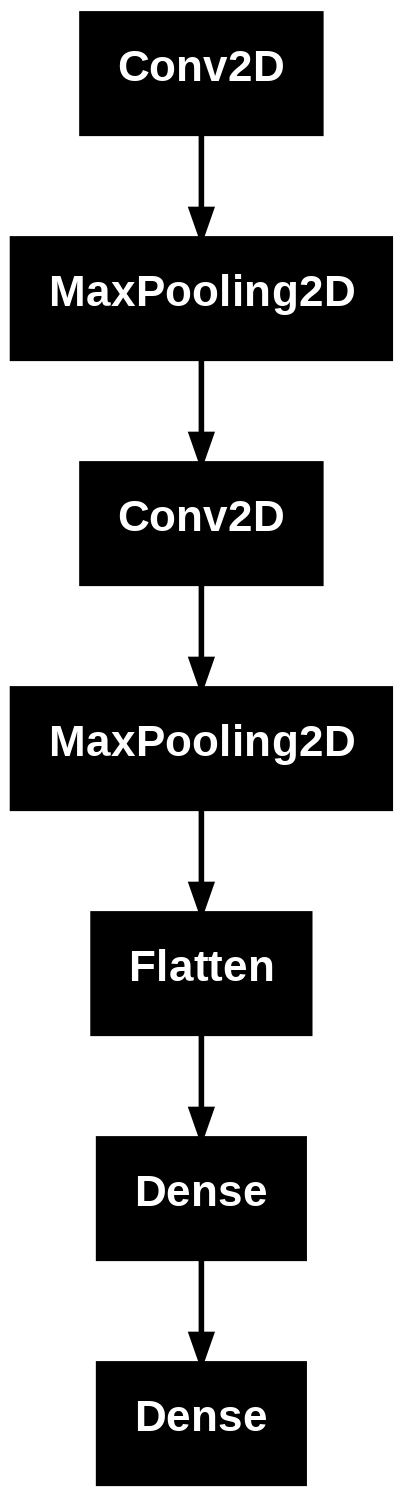

In [25]:
tf.keras.utils.plot_model(model)

In [26]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

In [27]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=['accuracy'])

In [28]:
h= model.fit(training_images, training_labels, epochs=50,
             validation_data=(test_images, test_labels),
             callbacks = [model_ckp, stop])

Epoch 1/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7997 - loss: 0.5547

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 99s 52ms/step - accuracy: 0.7998 - loss: 0.5545 - val_accuracy: 0.8933 - val_loss: 0.3038
Epoch 2/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9012 - loss: 0.2682

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 51ms/step - accuracy: 0.9012 - loss: 0.2682 - val_accuracy: 0.8993 - val_loss: 0.2814
Epoch 3/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9212 - loss: 0.2157

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - accuracy: 0.9212 - loss: 0.2157 - val_accuracy: 0.9120 - val_loss: 0.2390
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9342 - loss: 0.1825

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 51ms/step - accuracy: 0.9342 - loss: 0.1825 - val_accuracy: 0.9155 - val_loss: 0.2455
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 95s 51ms/step - accuracy: 0.9428 - loss: 0.1548 - val_accuracy: 0.9147 - val_loss: 0.2341
Epoch 6/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9518 - loss: 0.1289

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 51ms/step - accuracy: 0.9517 - loss: 0.1289 - val_accuracy: 0.9191 - val_loss: 0.2399
Epoch 7/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9573 - loss: 0.1125

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 51ms/step - accuracy: 0.9573 - loss: 0.1125 - val_accuracy: 0.9207 - val_loss: 0.2498
Epoch 8/50
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9653 - loss: 0.0928

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 51ms/step - accuracy: 0.9653 - loss: 0.0928 - val_accuracy: 0.9233 - val_loss: 0.2583
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 51ms/step - accuracy: 0.9723 - loss: 0.0754 - val_accuracy: 0.9156 - val_loss: 0.2767
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 95s 51ms/step - accuracy: 0.9761 - loss: 0.0658 - val_accuracy: 0.9208 - val_loss: 0.3019
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 94s 50ms/step - accuracy: 0.9791 - loss: 0.0547 - val_accuracy: 0.9222 - val_loss: 0.3270


In [29]:
#  MSE : loss: 0.0704 - accuracy: 0.5393 - val_loss: 0.0682 - val_accuracy: 0.5872
#  CROSS ENTROPY : loss: 0.5450 - accuracy: 0.8112 - val_loss: 0.5563 - val_accuracy: 0.8020
#  Relu : loss: 0.4099 - accuracy: 0.8585 - val_loss: 0.4308 - val_accuracy: 0.8479
#  (20 epochs) : loss: 0.3009 - accuracy: 0.8936 - val_loss: 0.3549 - val_accuracy: 0.8744
#  model complexe : loss: 0.2473 - accuracy: 0.9109 - val_loss: 0.3229 - val_accuracy: 0.8847
#  Dropout : loss: 0.3238 - accuracy: 0.8834 - val_loss: 0.3361 - val_accuracy: 0.8800
#  Adam : loss: 0.8879 - accuracy: 0.6822 - val_loss: 0.6868 - val_accuracy: 0.7686
#  Callbacks : loss: 0.3065 - accuracy: 0.8892 - val_loss: 0.3300 - val_accuracy: 0.8801

#  CNN : loss: 0.1843 - accuracy: 0.9309 - val_loss: 0.2286 - val_accuracy: 0.9194